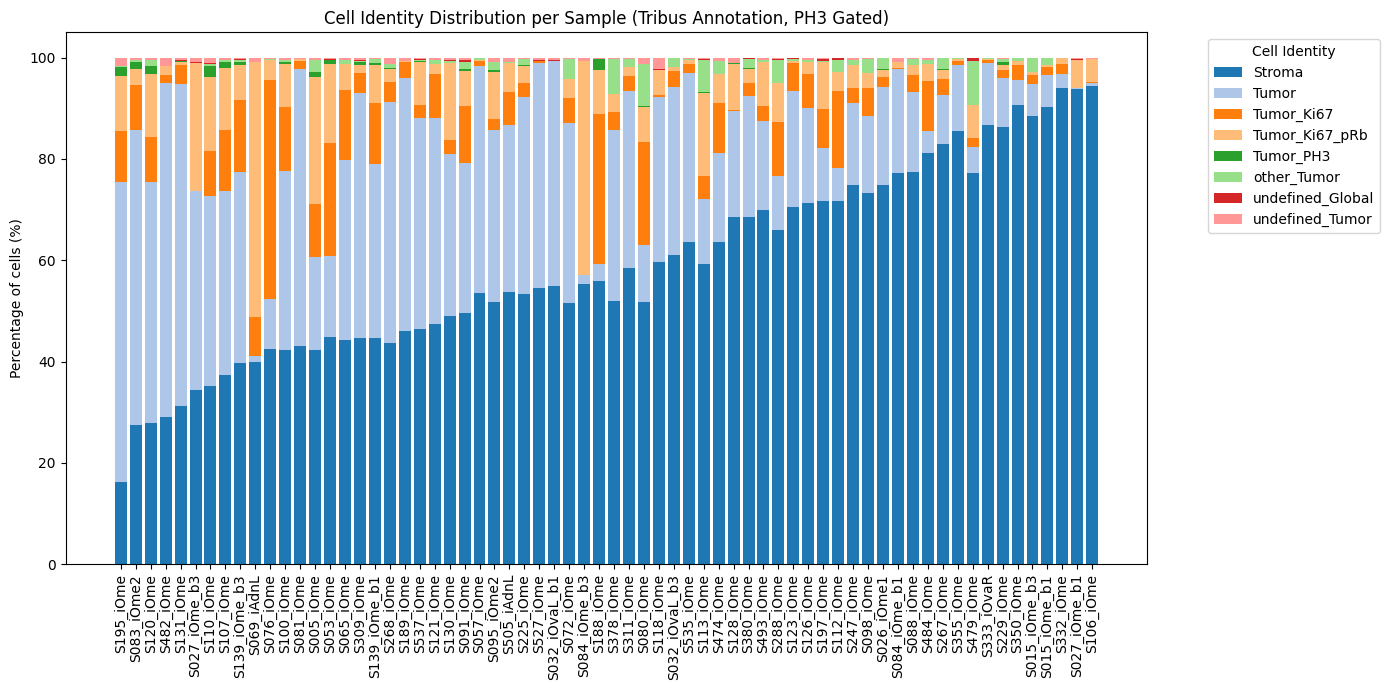

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

folder_path = "/Volumes/h30492/farkkilab2/4_CellCycle/tcycif/4_10_Expansion/Analysis/01-phenotyping/tribus/labels_for_phenotyped_cells/labels_PanCK_0_aSMA_1_pRb_combined_PH3_gated_600"

# Only annotation files that are PH3 gated
all_files = [
    f for f in os.listdir(folder_path)
    if f.endswith(".csv")
    and "_PH3_gated" in f
    and "11_tribus_annotation" in f
]

summary_list = []
sample_names = []

for file in all_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)

    if "final_label" not in df.columns:
        continue

    counts = df["final_label"].value_counts(normalize=True) * 100
    counts.name = os.path.splitext(file)[0]
    summary_list.append(counts)

    # Extract sample name before "_logic_table"
    sample_name = os.path.splitext(file)[0].split("_logic_table")[0]
    sample_names.append(sample_name)

# Combine into dataframe
summary_df = pd.DataFrame(summary_list).fillna(0)
summary_df.index = sample_names  # keep original order

# Sort label columns alphabetically
summary_df = summary_df.reindex(sorted(summary_df.columns), axis=1)

# ---- Determine bar order by total tumor proportion ----
tumor_cols = ["Tumor", "Tumor_PH3", "Tumor_Ki67_pRb", "Tumor_Ki67"]
existing_tumor_cols = [c for c in tumor_cols if c in summary_df.columns]

if existing_tumor_cols:
    total_tumor = summary_df[existing_tumor_cols].sum(axis=1)
    sorted_idx = total_tumor.sort_values(ascending=False).index
else:
    sorted_idx = summary_df.index  # fallback if none exist

# ---- Plot ----
plt.figure(figsize=(14, 7))

bottom = pd.Series(0, index=sorted_idx)

colors = plt.cm.tab20.colors
color_map = {label: colors[i % len(colors)] for i, label in enumerate(summary_df.columns)}

for label in summary_df.columns:
    plt.bar(
        sorted_idx,
        summary_df.loc[sorted_idx, label],
        bottom=bottom,
        color=color_map[label],
        label=label
    )
    bottom += summary_df.loc[sorted_idx, label]

plt.xticks(rotation=90)
plt.ylabel("Percentage of cells (%)")
plt.title("Cell Identity Distribution per Sample (Tribus Annotation, PH3 Gated)")

plt.legend(title="Cell Identity", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

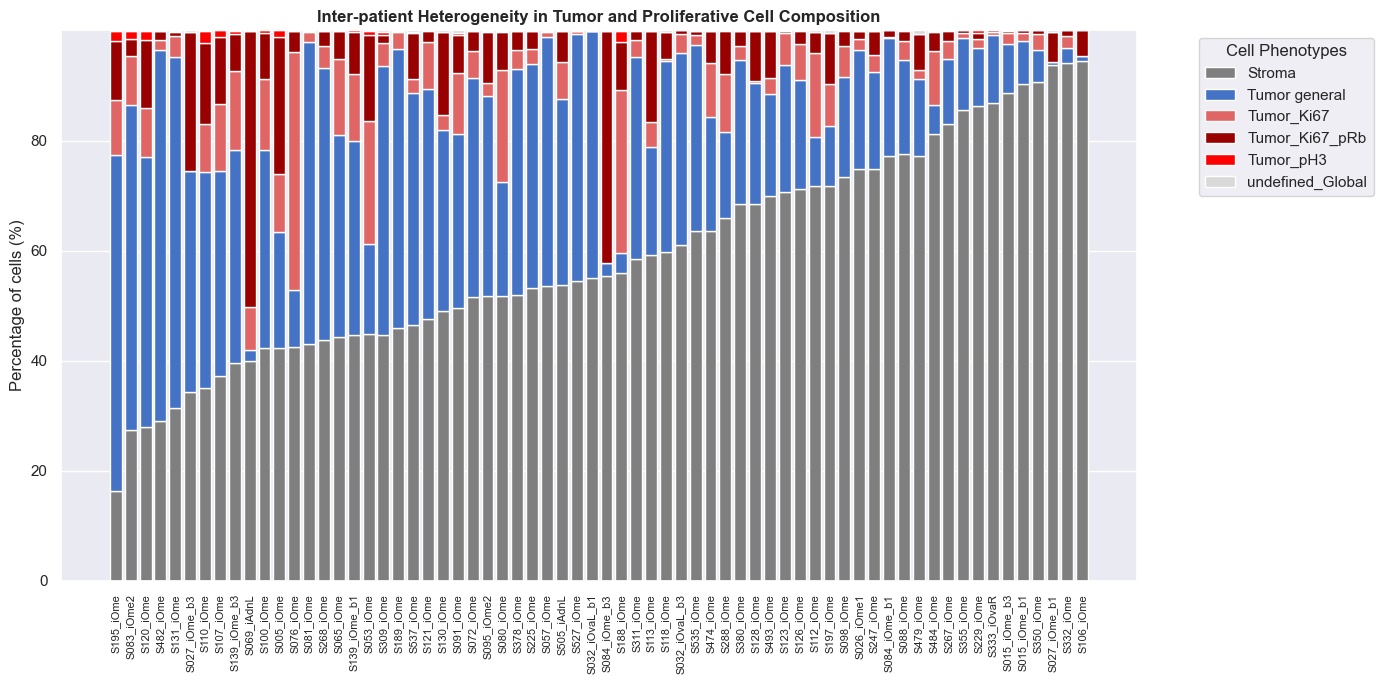


Number of samples analyzed: 66
Minimum percentage of proliferative cells: 0.10%
Maximum percentage of proliferative cells: 57.95%



In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Define the folder path containing your TRIBUS annotation files
folder_path = "/Volumes/h30492/farkkilab2/4_CellCycle/tcycif/4_10_Expansion/Analysis/01-phenotyping/tribus/labels_for_phenotyped_cells/labels_PanCK_0_aSMA_1_pRb_combined_PH3_gated_600"

# Custom color mapping to ensure consistency with your spatial niche diagrams
custom_colors = {
    'Stroma': '#7F7F7F',             # Grey
    'Tumor general': '#4472C4',      # Blue (Merged category)
    'Tumor_Ki67': '#E06666',         # Light Red
    'Tumor_Ki67_pRb': '#990000',     # Dark Red
    'Tumor_pH3': '#FF0000',          # Bright Red for mitotic cells (Updated to pH3)
    'undefined_Global': '#D9D9D9'    # Light Grey
}

# Filter for PH3 gated annotation files
all_files = [
    f for f in os.listdir(folder_path)
    if f.endswith(".csv")
    and "_PH3_gated" in f
    and "11_tribus_annotation" in f
]

summary_list = []
sample_names = []

for file in all_files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path)

    if "final_label" not in df.columns:
        continue

    # --- MERGING LOGIC ---
    # Merge Tumor, other_Tumor, and undefined_Tumor into 'Tumor general'
    # Also rename Tumor_PH3 to Tumor_pH3 for consistent plotting
    merge_map = {
        'Tumor': 'Tumor general',
        'other_Tumor': 'Tumor general',
        'undefined_Tumor': 'Tumor general',
        'Tumor_PH3': 'Tumor_pH3'
    }
    df['final_label'] = df['final_label'].replace(merge_map)

    # Calculate percentages
    counts = df["final_label"].value_counts(normalize=True) * 100
    counts.name = os.path.splitext(file)[0]
    summary_list.append(counts)

    # Extract clean sample name for the x-axis
    sample_name = os.path.splitext(file)[0].split("_logic_table")[0]
    sample_names.append(sample_name)

# Combine results into a single DataFrame
summary_df = pd.DataFrame(summary_list).fillna(0)
summary_df.index = sample_names 

# Sort columns for consistent legend and stacking
summary_df = summary_df.reindex(sorted(summary_df.columns), axis=1)

# ---- Determine bar order by total tumor proportion (now including merged category) ----
tumor_cols = ["Tumor general", "Tumor_pH3", "Tumor_Ki67_pRb", "Tumor_Ki67"]
existing_tumor_cols = [c for c in tumor_cols if c in summary_df.columns]

if existing_tumor_cols:
    total_tumor = summary_df[existing_tumor_cols].sum(axis=1)
    sorted_idx = total_tumor.sort_values(ascending=False).index
else:
    sorted_idx = summary_df.index

# ---- Plotting ----
plt.figure(figsize=(14, 7))
bottom = pd.Series(0, index=sorted_idx)

for label in summary_df.columns:
    color = custom_colors.get(label, '#CCCCCC') # Fallback to neutral grey if label missing
    plt.bar(
        sorted_idx,
        summary_df.loc[sorted_idx, label],
        bottom=bottom,
        color=color,
        label=label
    )
    bottom += summary_df.loc[sorted_idx, label]

plt.xticks(rotation=90, fontsize=8)
plt.ylabel("Percentage of cells (%)")

# Corrected Title: Now in Bold
plt.title("Inter-patient Heterogeneity in Tumor and Proliferative Cell Composition", fontweight='bold')

plt.legend(title="Cell Phenotypes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---- Print Requested Statistics ----
# Define proliferative cells based on the custom colors dictionary
proliferative_cols = ["Tumor_pH3", "Tumor_Ki67_pRb", "Tumor_Ki67"]
existing_prolif_cols = [c for c in proliferative_cols if c in summary_df.columns]

if existing_prolif_cols:
    # Sum the proliferative columns row-wise
    total_proliferative = summary_df[existing_prolif_cols].sum(axis=1)
    min_prolif = total_proliferative.min()
    max_prolif = total_proliferative.max()
else:
    min_prolif = 0.0
    max_prolif = 0.0

num_samples = len(summary_df)

print("\n" + "="*50)
print(f"Number of samples analyzed: {num_samples}")
print(f"Minimum percentage of proliferative cells: {min_prolif:.2f}%")
print(f"Maximum percentage of proliferative cells: {max_prolif:.2f}%")
print("="*50 + "\n")